# Polychromatic propagation

Fiatlux keeps wavelength as an explicit dimension of the optical field.

A field is therefore expected to follow the convention

`(n_wavelengths, ny, nx)`.

In this example we simulate a PSF across the H band.

In [1]:
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from fiatlux.core.grid import Grid
from fiatlux.core.spectrum import PhotometricBand, Spectrum
from fiatlux.core.source import PlaneWave
from fiatlux.optics.elements.mask import CircularAperture
from fiatlux.optics.propagator import MFTPropagator
from fiatlux.system.optical_system import SerialSystem

In [2]:
D = 1.0
focal_length = 10.0
central_wavelength = 1.65e-6

N_pupil = 256
N_focal = 256

pupil_grid = Grid(
    nx=N_pupil,
    ny=N_pupil,
    dx=D / N_pupil,
    dy=D / N_pupil,
)

focal_grid = Grid(
    nx=N_focal,
    ny=N_focal,
    dx=focal_length * central_wavelength / D / 4,
    dy=focal_length * central_wavelength / D / 4,
)

## Create an H-band spectrum

In [3]:
spectrum_H = Spectrum(
    magnitude=8,
    band=PhotometricBand.H,
    samples=7,
)

source_H = PlaneWave(spectrum_H)

print("Wavelengths [µm]:")
for wavelength_i in spectrum_H.wavelengths:
    print(f"{float(wavelength_i) * 1e6:.3f}")

Wavelengths [µm]:
1.509
1.557
1.606
1.654
1.702
1.751
1.799


## Propagate the polychromatic field

In [4]:
aperture = CircularAperture(
    grid=pupil_grid,
    radius=D / 2,
)

propagator = MFTPropagator(
    focal_length=focal_length,
    output_grid=focal_grid,
)

system_H = SerialSystem(
    elements=[
        aperture,
        propagator,
    ]
)

result_H = system_H.run(source_H)
field_H = result_H.field_at(propagator)

print("Intensity shape:", field_H.intensity().shape)

Intensity shape: torch.Size([7, 256, 256])


## Display each wavelength separately

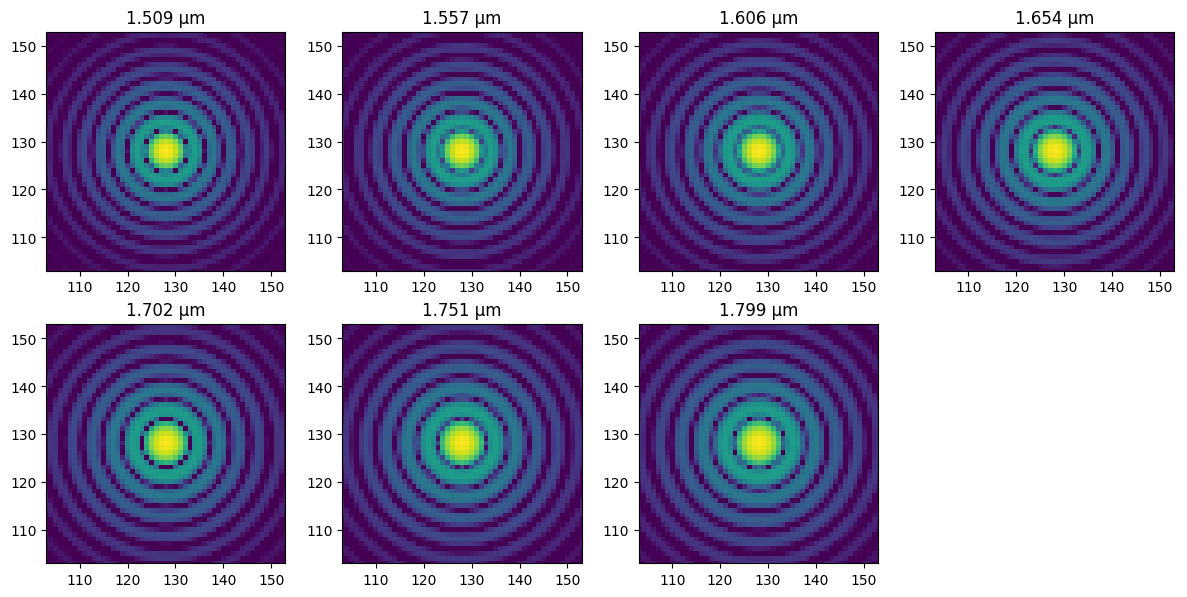

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    if i >= len(spectrum_H.wavelengths):
        ax.axis("off")
        continue

    image = field_H.intensity()[i]
    image = image / image.max()

    ax.imshow(
        image.cpu(),
        origin="lower",
        norm=LogNorm(vmin=1e-4, vmax=1),
    )

    ax.set_title(f"{float(spectrum_H.wavelengths[i]) * 1e6:.3f} µm")

    ax.set_xlim(N_focal // 2 - 25, N_focal // 2 + 25)
    ax.set_ylim(N_focal // 2 - 25, N_focal // 2 + 25)

plt.tight_layout()
plt.show()

## Sum the wavelength channels to obtain the broadband PSF

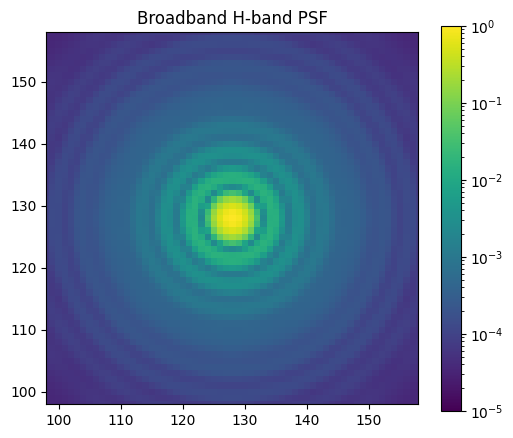

In [6]:
broadband_psf = field_H.intensity().sum(dim=0)
broadband_psf = broadband_psf / broadband_psf.max()

plt.figure(figsize=(6, 5))
plt.imshow(
    broadband_psf.cpu(),
    origin="lower",
    norm=LogNorm(vmin=1e-5, vmax=1),
)

plt.xlim(N_focal // 2 - 30, N_focal // 2 + 30)
plt.ylim(N_focal // 2 - 30, N_focal // 2 + 30)

plt.title("Broadband H-band PSF")
plt.colorbar()
plt.show()